# Netflix Content Strategy Analysis

# Objective
The goal of this analysis is to understand Netflix's content strategy, growth patterns, and user behavior using the dataset.

# Key Questions
- How has Netflix grown over time?
- What type of content dominates (Movies vs TV Shows)?
- What are the most popular genres and ratings?
- How does content vary across countries?
- What strategic insights can be derived?

## Dataset Overview

This dataset contains information about Netflix titles including:
- Title
- Type (Movie / TV Show)
- Release Year
- Country
- Genre
- Duration
- Rating

We will analyze trends across time, geography, and content type.

In [15]:
oldest_year = df['release_year'].min()
newest_year = df['release_year'].max()

print("Oldest Release Year:", oldest_year)
print("Newest Release Year:", newest_year)

Oldest Release Year: 1925
Newest Release Year: 2021


## Data Cleaning & Preprocessing

Before analysis, we clean the dataset by:
- Handling missing values
- Converting date columns
- Splitting multi-value columns (country, genre)
- Removing inconsistencies

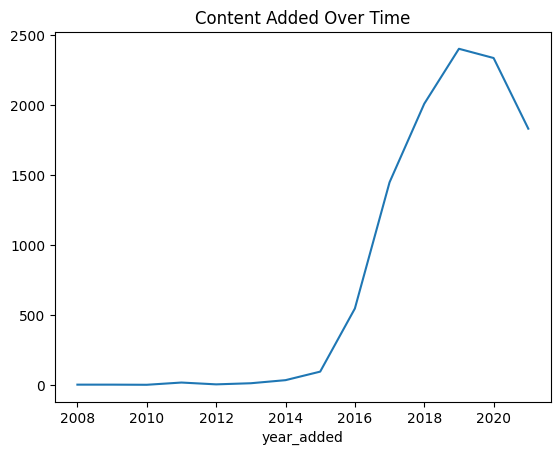

In [16]:
# ===============================
# 1. IMPORT LIBRARIES
# ===============================
import pandas as pd

import matplotlib.pyplot as plt
import os
import shutil

# ===============================
# 2. LOAD DATASET (KAGGLE PATH)
# ===============================
df = pd.read_csv("/kaggle/input/netflix-dataset/netflix_titles.csv")


# Fill missing values
df['director'] = df['director'].fillna('')
df['cast'] = df['cast'].fillna('')
df['country'] = df['country'].fillna('')
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
# Convert date_added safely
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Drop missing critical values
df = df.dropna(subset=['date_added', 'country'])

# Extract year
df['year_added'] = df['date_added'].dt.year
# Split and explode country column
df['country'] = df['country'].str.split(',')
df = df.explode('country')

# Clean spaces
df['country'] = df['country'].str.strip()

# Helper function
def explode_column(df, col):
    return df.assign(**{col: df[col].str.split(', ')}).explode(col)

df['year_added'].value_counts().sort_index().plot(kind='line')
plt.title("Content Added Over Time")
plt.show()


Top Directors:
 director
Rajiv Chilaka       22
Jan Suter           21
Raúl Campos         19
Martin Scorsese     18
Steven Spielberg    18
Youssef Chahine     17
Suhas Kadav         16
Marcus Raboy        16
Martin Campbell     15
Jay Karas           15
Name: count, dtype: int64

Top Actors:
 cast
Anupam Kher           46
David Attenborough    45
Vincent Tong          40
John Cleese           40
Tara Strong           39
Shah Rukh Khan        38
Liam Neeson           36
Andrea Libman         36
Alfred Molina         35
James Franco          35
Name: count, dtype: int64

Top Countries:
 country
United States     3643
India             1045
United Kingdom     787
Canada             432
France             389
Japan              314
Spain              228
South Korea        226
Germany            225
Mexico             169
Name: count, dtype: int64

Top Release Years:
 release_year
2018    1383
2017    1260
2019    1208
2016    1128
2020    1055
2015     714
2021     658
2014     472
2013

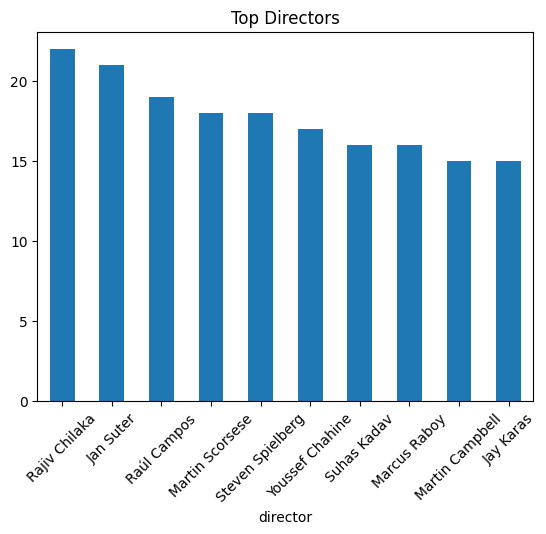

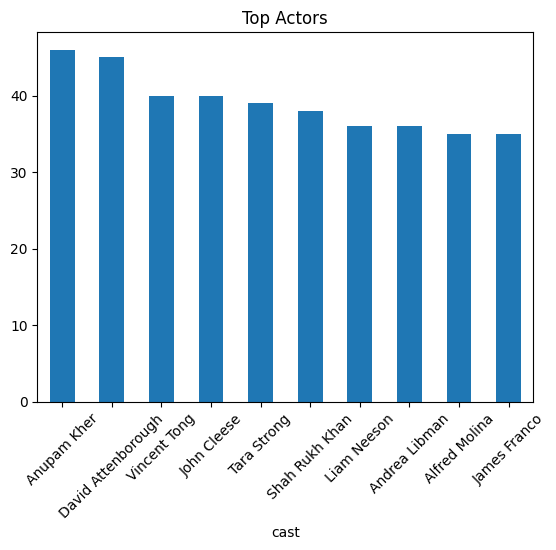

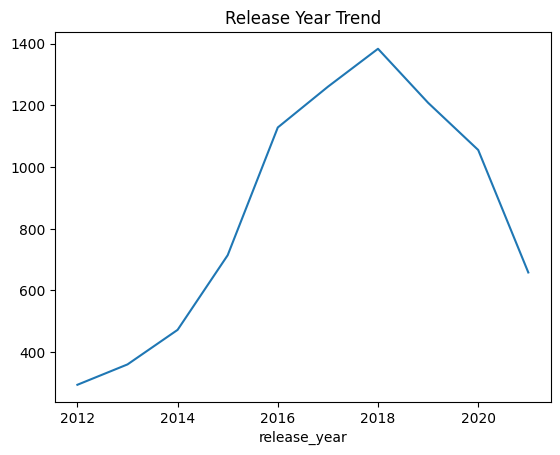

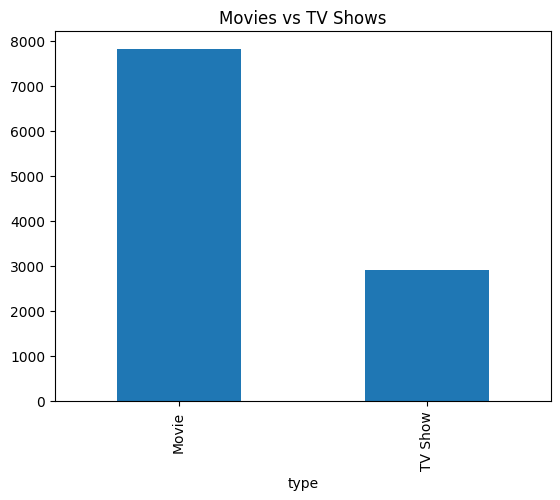

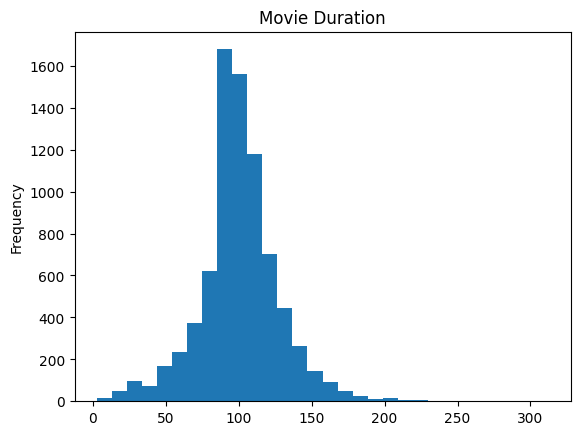

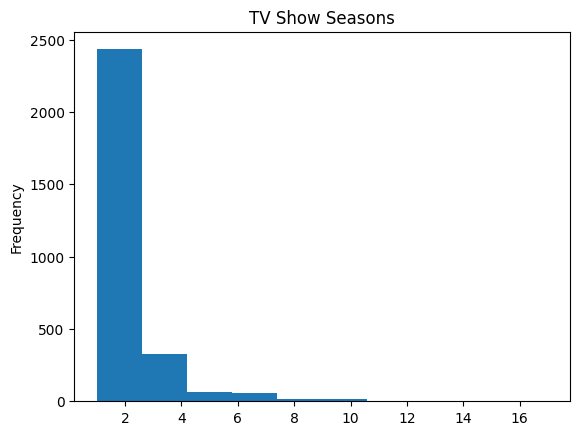

In [17]:


# ===============================
# 3. DIRECTORS
# ===============================
director_df = explode_column(df, 'director')
top_directors = director_df['director'].value_counts().drop('').head(10)

print("\nTop Directors:\n", top_directors)

# ===============================
# 4. ACTORS
# ===============================
cast_df = explode_column(df, 'cast')
top_actors = cast_df['cast'].value_counts().drop('').head(10)

print("\nTop Actors:\n", top_actors)

# ===============================
# 5. COUNTRIES
# ===============================
country_df = explode_column(df, 'country')
top_countries = country_df['country'].value_counts().drop('').head(10)

print("\nTop Countries:\n", top_countries)

# ===============================
# 6. RELEASE YEARS
# ===============================
top_years = df['release_year'].value_counts().head(10)

print("\nTop Release Years:\n", top_years)

# ===============================
# 7. TYPE DISTRIBUTION
# ===============================
type_counts = df['type'].value_counts()

print("\nContent Type:\n", type_counts)

# ===============================
# 8. DURATION FIXED (NO WARNING)
# ===============================
movies = df[df['type'] == 'Movie'].copy()
movies.loc[:, 'duration_int'] = movies['duration'].str.replace(' min', '').astype(float)

tv = df[df['type'] == 'TV Show'].copy()
tv.loc[:, 'duration_int'] = tv['duration'].str.replace(' Season', '').str.replace('s', '').astype(float)

print("\nMovie Duration Stats:\n", movies['duration_int'].describe())
print("\nTV Show Duration Stats:\n", tv['duration_int'].describe())

# ===============================
# 9. CREATE OUTPUT FOLDER
# ===============================
output_path = "/kaggle/working/ott_outputs"
os.makedirs(output_path, exist_ok=True)

# ===============================
# 10. SAVE GRAPHS
# ===============================

# Directors
plt.figure()
top_directors.plot(kind='bar')
plt.title("Top Directors")
plt.xticks(rotation=45)
plt.savefig(f"{output_path}/top_directors.png")


# Actors
plt.figure()
top_actors.plot(kind='bar')
plt.title("Top Actors")
plt.xticks(rotation=45)
plt.savefig(f"{output_path}/top_actors.png")


# Countries
plt.figure()
top_countries.plot(kind='bar')
plt.title("Top Countries")
plt.xticks(rotation=45)
plt.savefig(f"{output_path}/top_countries.png")
plt.close()

# Release Year
plt.figure()
top_years.sort_index().plot(kind='line')
plt.title("Release Year Trend")
plt.savefig(f"{output_path}/release_year.png")


# Type Distribution
plt.figure()
type_counts.plot(kind='bar')
plt.title("Movies vs TV Shows")
plt.savefig(f"{output_path}/type_distribution.png")


# Movie Duration
plt.figure()
movies['duration_int'].plot(kind='hist', bins=30)
plt.title("Movie Duration")
plt.savefig(f"{output_path}/movie_duration.png")

# TV Duration
plt.figure()
tv['duration_int'].plot(kind='hist', bins=10)
plt.title("TV Show Seasons")
plt.savefig(f"{output_path}/tv_duration.png")

# ===============================
# 11. SAVE CSV FILES
# ===============================
top_directors.to_csv(f"{output_path}/top_directors.csv")
top_actors.to_csv(f"{output_path}/top_actors.csv")
top_countries.to_csv(f"{output_path}/top_countries.csv")
top_years.to_csv(f"{output_path}/top_years.csv")

# ===============================
# 12. ZIP EVERYTHING
# ===============================
shutil.make_archive("/kaggle/working/ott_analysis", 'zip', output_path)

print("\n✅ DONE!")
print("📥 Download from: Output → /kaggle/working → ott_analysis.zip")

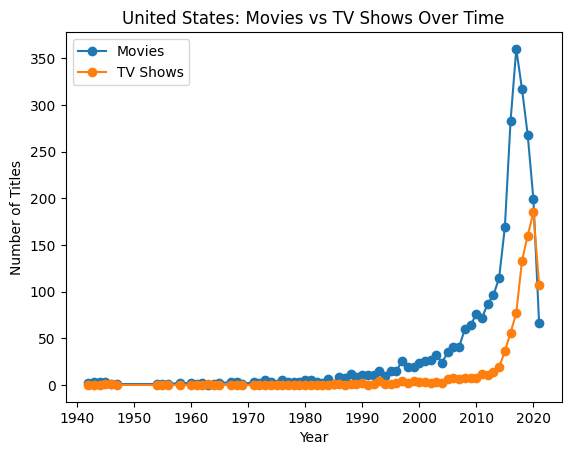

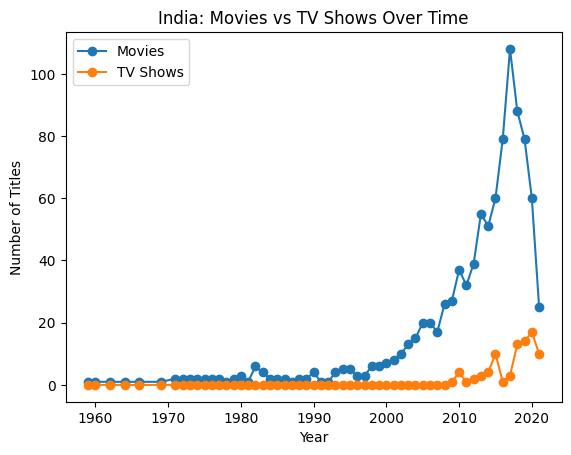

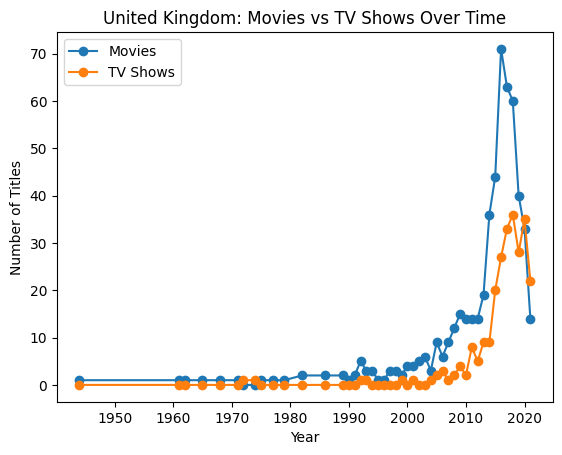

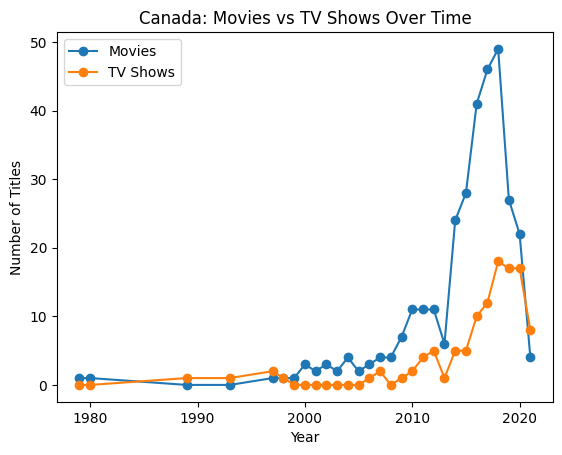

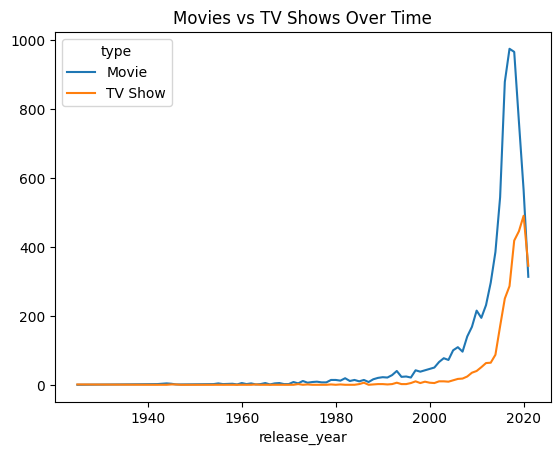

In [18]:
# ===============================
# YEAR + COUNTRY + TYPE ANALYSIS
# ===============================

import pandas as pd
import matplotlib.pyplot as plt

# Explode country column
country_df = df.assign(country=df['country'].str.split(', ')).explode('country')
country_df = country_df[country_df['country'] != '']

# Select top 4 countries (to avoid clutter)
top_countries = country_df['country'].value_counts().head(4).index

# ===============================
# PLOT FOR EACH COUNTRY
# ===============================
for country in top_countries:
    
    temp = country_df[country_df['country'] == country]
    
    # Group by year and type
    trend = temp.groupby(['release_year', 'type']).size().unstack().fillna(0)
    trend = trend.sort_index()
    
    # Plot
    plt.figure()
    
    if 'Movie' in trend.columns:
        plt.plot(trend.index, trend['Movie'], marker='o', label='Movies')
        
    if 'TV Show' in trend.columns:
        plt.plot(trend.index, trend['TV Show'], marker='o', label='TV Shows')
    
    plt.title(f"{country}: Movies vs TV Shows Over Time")
    plt.xlabel("Year")
    plt.ylabel("Number of Titles")
    plt.legend()
    
    plt.show()

trend = df.groupby(['release_year', 'type']).size().unstack().fillna(0)

trend.plot()
plt.title("Movies vs TV Shows Over Time")
plt.show()

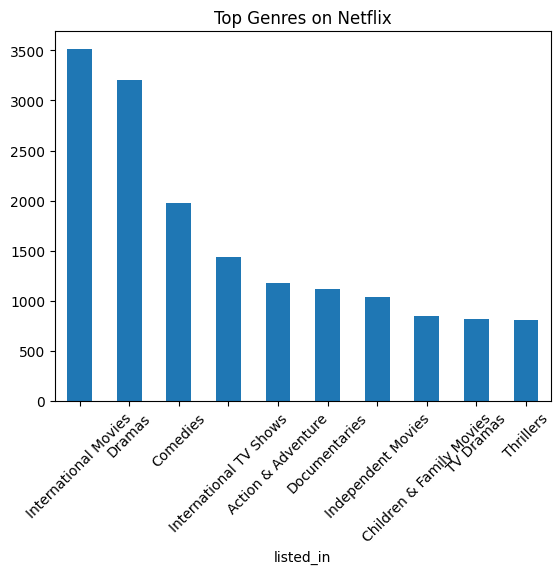

In [19]:
genre_df = df.assign(listed_in=df['listed_in'].str.split(', ')).explode('listed_in')

top_genres = genre_df['listed_in'].value_counts().head(10)

plt.figure()
top_genres.plot(kind='bar')
plt.title("Top Genres on Netflix")
plt.xticks(rotation=45)
plt.show()

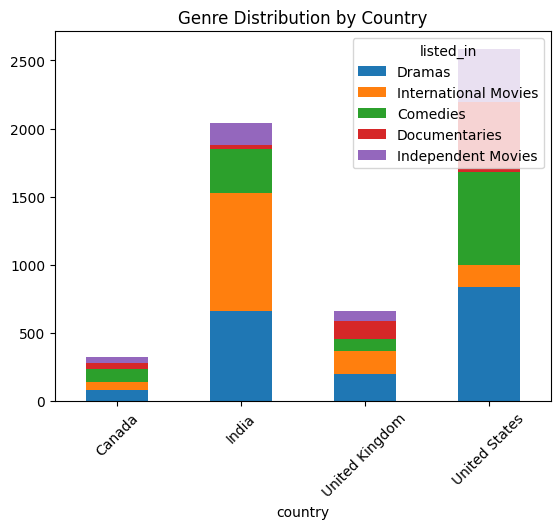

In [20]:
country_genre = df.assign(
    country=df['country'].str.split(', '),
    listed_in=df['listed_in'].str.split(', ')
).explode('country').explode('listed_in')

top = country_genre[country_genre['country'].isin(top_countries)]

pivot = top.groupby(['country', 'listed_in']).size().unstack().fillna(0)

pivot.loc[:, pivot.sum().sort_values(ascending=False).head(5).index].plot(kind='bar', stacked=True)
plt.title("Genre Distribution by Country")
plt.xticks(rotation=45)
plt.show()

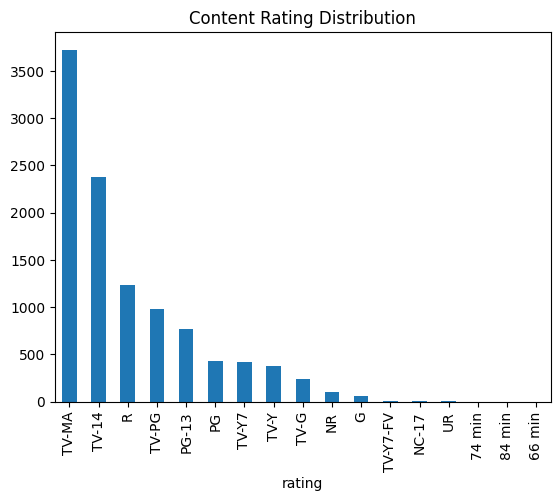

In [21]:
rating_counts = df['rating'].value_counts()

rating_counts.plot(kind='bar')
plt.title("Content Rating Distribution")
plt.show()

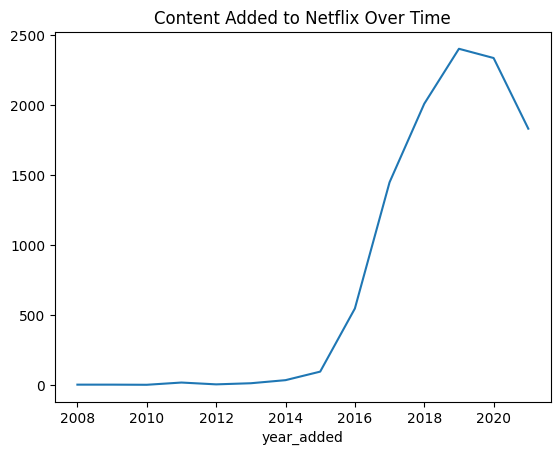

In [22]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year

added_trend = df['year_added'].value_counts().sort_index()

added_trend.plot()
plt.title("Content Added to Netflix Over Time")
plt.show()

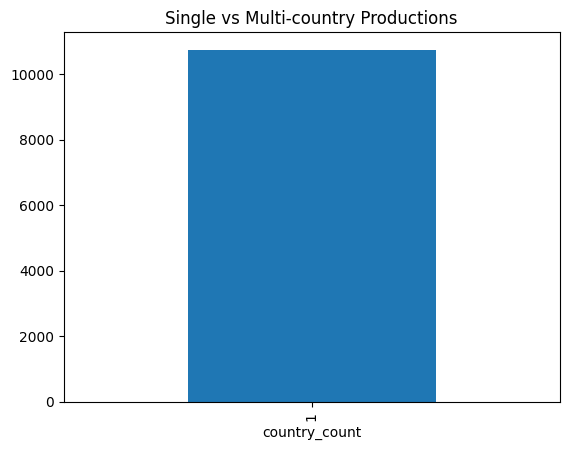

In [23]:
df['country_count'] = df['country'].apply(lambda x: len(str(x).split(',')))

df['country_count'].value_counts().plot(kind='bar')
plt.title("Single vs Multi-country Productions")
plt.show()

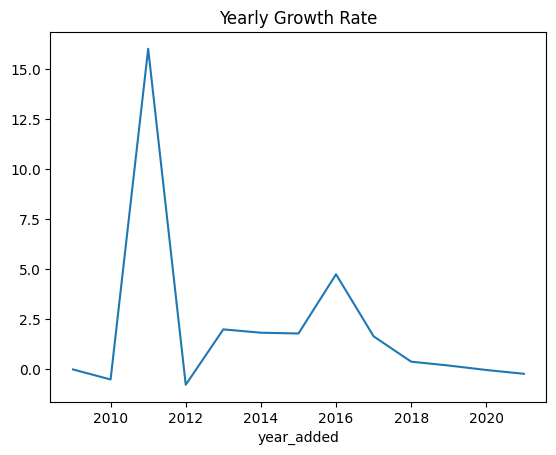

In [24]:
growth = added_trend.pct_change()

growth.plot()
plt.title("Yearly Growth Rate")
plt.show()

## Business Recommendations:

1. Maintain strong movie production to support user acquisition
2. Increase investment in high-quality TV Shows to improve retention and engagement
3. Focus on localized content strategies in key markets like India and UK
4. Optimize content strategy in mature markets where growth has slowed post-2020
5. Adapt content planning to external shocks (e.g., COVID), ensuring supply continuity during demand spikes

## CONCLUSION
Netflix’s content library analysis reveals a strong strategic emphasis on rapid expansion between 2016 and 2019, followed by stabilization post-2020. The dominance of movies suggests a focus on scalable content acquisition, while the gradual rise of TV shows indicates a shift toward retention-driven strategies.

However, since this dataset reflects content availability rather than user engagement, the insights primarily represent Netflix’s strategic decisions rather than direct audience preferences. Therefore, conclusions about user behavior should be interpreted cautiously and ideally supplemented with user-level data such as watch time, ratings, or retention metrics.